<a href="https://colab.research.google.com/github/Escalada-Matthew/CPE-311/blob/main/MidtermQuiz_Escalada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
#Extract

In [16]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("supplejade/rt-iot2022real-time-internet-of-things")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'rt-iot2022real-time-internet-of-things' dataset.
Path to dataset files: /kaggle/input/rt-iot2022real-time-internet-of-things


In [17]:
import pandas as pd
import os

files = os.listdir(path)
print("Files in directory:", files)

csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

df = pd.read_csv(full_path)

df.head()

Files in directory: ['RT_IOT2022.csv']


,no,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [18]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (123117, 85)


In [30]:
#Transform

In [19]:

num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {num_duplicates}")



Number of duplicate rows found: 0


In [25]:
has_nulls = df.isnull().values.any()
print(f"\nDoes the dataset contain any null values? {has_nulls}")




Does the dataset contain any null values? False


In [28]:
#Load

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

key_features = ['flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'payload_bytes_per_second']
print("Descriptive Statistics for Network Traffic:")
print(df[key_features].describe())

Descriptive Statistics for Network Traffic:
       flow_duration   fwd_pkts_tot   bwd_pkts_tot  payload_bytes_per_second
count  123117.000000  123117.000000  123117.000000              1.231170e+05
mean        3.809566       2.268826       1.909509              4.105345e+07
std       130.005408      22.336565      33.018311              4.485706e+07
min         0.000000       0.000000       0.000000              0.000000e+00
25%         0.000001       1.000000       1.000000              2.580981e+03
50%         0.000004       1.000000       1.000000              2.960685e+07
75%         0.000005       1.000000       1.000000              5.592405e+07
max     21728.335578    4345.000000   10112.000000              1.258291e+08


/tmp/ipykernel_281/3511592232.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Attack_type', palette='magma', order=df['Attack_type'].value_counts().index)


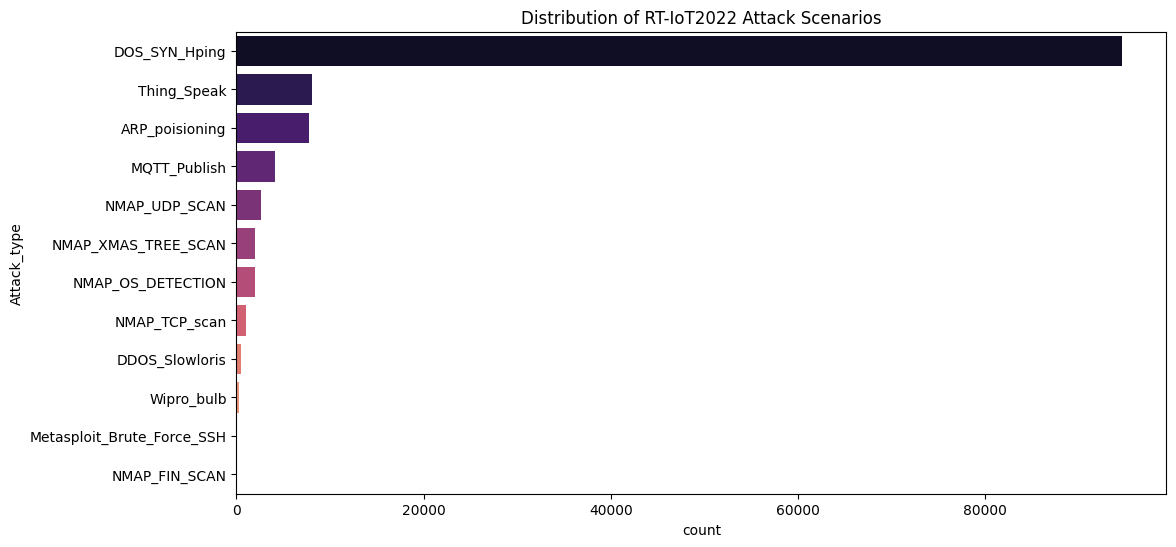

In [34]:
# Threat Landscape plot
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Attack_type', palette='magma', order=df['Attack_type'].value_counts().index)
plt.title('Distribution of RT-IoT2022 Attack Scenarios')
plt.show()

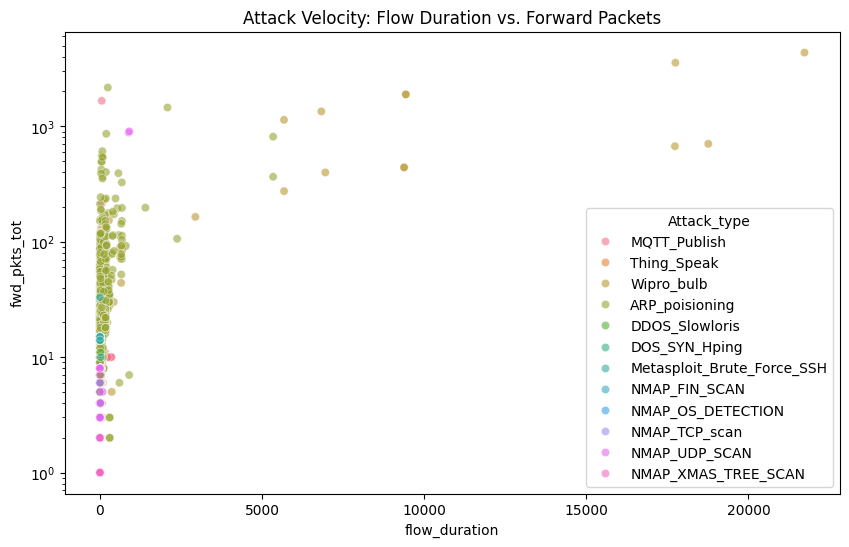

In [35]:
# Attack Velocity
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='flow_duration', y='fwd_pkts_tot', hue='Attack_type', alpha=0.6)
plt.yscale('log') # Log scale helps manage extreme outliers in packet counts
plt.title('Attack Velocity: Flow Duration vs. Forward Packets')
plt.show()

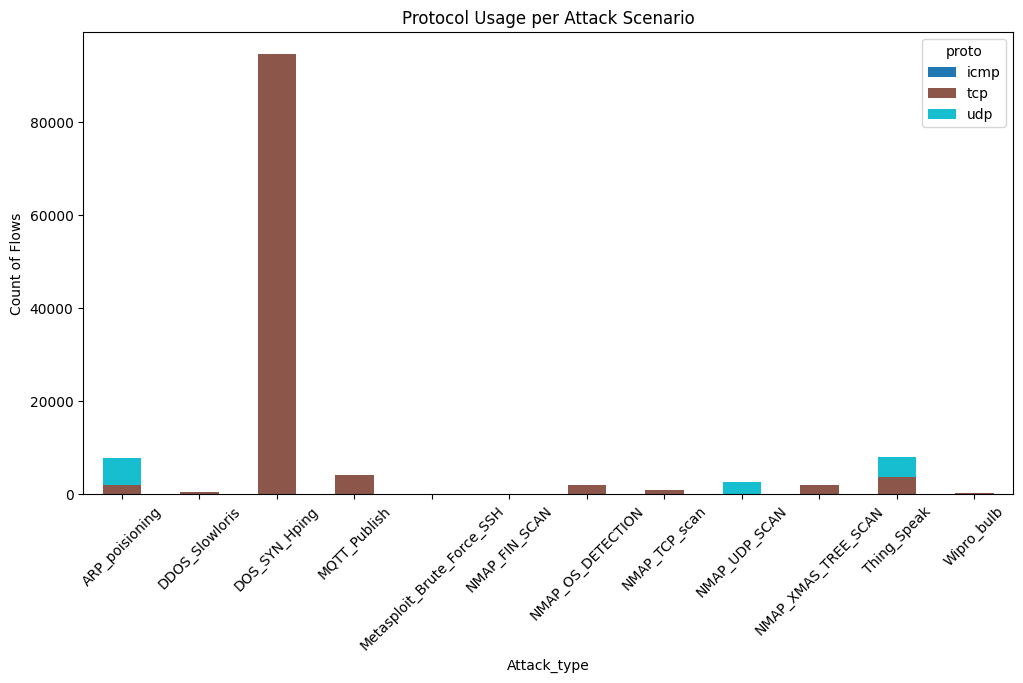

In [36]:
#Protocol Fingerprinting
protocol_pivot = pd.crosstab(df['Attack_type'], df['proto'])
protocol_pivot.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')
plt.title('Protocol Usage per Attack Scenario')
plt.xticks(rotation=45)
plt.ylabel('Count of Flows')
plt.show()

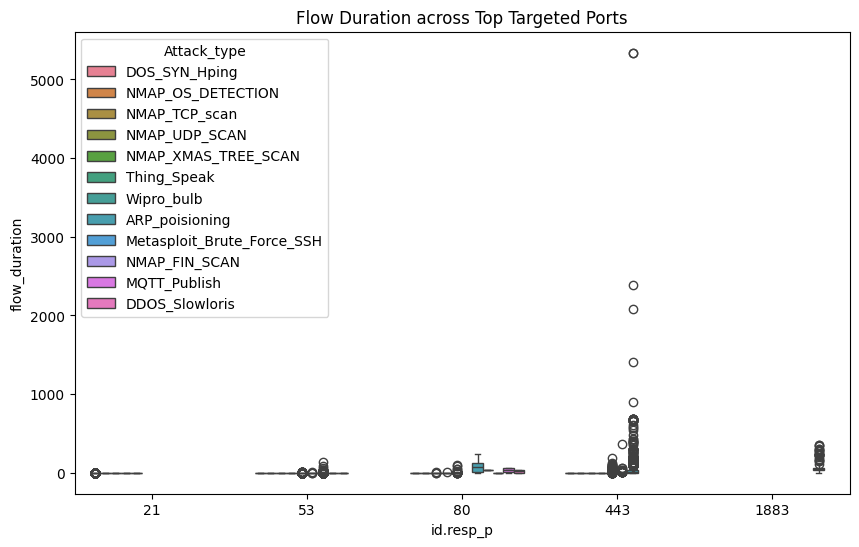

In [37]:
#Port Targeting
top_ports = df['id.resp_p'].value_counts().nlargest(5).index
df_ports = df[df['id.resp_p'].isin(top_ports)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_ports, x='id.resp_p', y='flow_duration', hue='Attack_type')
plt.title('Flow Duration across Top Targeted Ports')
plt.show()